# 3. Prediksi Sentimen

Memberi label sentimen (**positive / negative / neutral**) ke setiap tweet memakai model yang sudah disediakan:
- `feature-bow.p` → CountVectorizer (Bag of Words), mengubah teks jadi angka
- `model-nb.p` → Multinomial Naive Bayes (model utama, sama seperti laprak)
- `model-nn.p` → Neural Network / MLPClassifier (sebagai pembanding)

Input : `data/<keyword>_clean.csv`
Output: `data/<keyword>_predicted.csv`

## Load model
Peringatan `InconsistentVersionWarning` boleh diabaikan (model dibuat dengan scikit-learn versi lama, tapi tetap berfungsi).

In [1]:
import pickle
import warnings
warnings.filterwarnings("ignore")

feature_bow = pickle.load(open("model/feature-bow.p", "rb"))
model_nb = pickle.load(open("model/model-nb.p", "rb"))
model_nn = pickle.load(open("model/model-nn.p", "rb"))

print("Feature :", type(feature_bow).__name__, "| jumlah kosakata:", len(feature_bow.vocabulary_))
print("Model NB:", type(model_nb).__name__, "| label:", [str(c) for c in model_nb.classes_])
print("Model NN:", type(model_nn).__name__, "| label:", [str(c) for c in model_nn.classes_])

Feature : CountVectorizer | jumlah kosakata: 18134
Model NB: MultinomialNB | label: ['negative', 'neutral', 'positive']
Model NN: MLPClassifier | label: ['negative', 'neutral', 'positive']


## Load dataset yang sudah clean

In [2]:
import pandas as pd

KEYWORD = "karhutla"  
data = pd.read_csv(f"data/{KEYWORD}_clean.csv").dropna()
print("Jumlah tweet:", len(data))
data.head()

Jumlah tweet: 261


,full_text
0,penegakan hukum karhutla memang bergerak tetap...
1,kejagung menerima spdp perkara pidana karhutla...
2,polsek menjalin edukasi warga cegah karhutla s...
3,karhutla di amburawang laut meluas tim gabunga...
4,di tengah kepungan api dan asap orangutan beru...


## Fungsi prediksi sentimen
Alurnya: teks → `feature_bow.transform` (jadi angka) → `model.predict` (jadi label).

In [3]:
def predict_sentiment(sent):
    # feature extraction
    text_feature = feature_bow.transform([sent])
    # predict
    return model_nb.predict(text_feature)[0]

# coba dulu di beberapa kalimat
for kal in ["asap karhutla bikin sesak napas parah",
            "salut untuk petugas pemadam yang bekerja keras",
            "bnpb merilis data titik panas hari ini"]:
    print(f"{kal!r:55} -> {predict_sentiment(kal)}")

'asap karhutla bikin sesak napas parah'                 -> negative
'salut untuk petugas pemadam yang bekerja keras'        -> positive
'bnpb merilis data titik panas hari ini'                -> neutral


In [4]:
data['sentiment'] = data['full_text'].apply(predict_sentiment)
data

,full_text,sentiment
0,penegakan hukum karhutla memang bergerak tetap...,negative
1,kejagung menerima spdp perkara pidana karhutla...,negative
2,polsek menjalin edukasi warga cegah karhutla s...,positive
3,karhutla di amburawang laut meluas tim gabunga...,neutral
4,di tengah kepungan api dan asap orangutan beru...,neutral
...,...,...
256,perkara apa mereka kesel sama kita gara asep k...,negative
257,jends menurut kalian kl cowo pacarmu gamau dia...,negative
258,bnpb jumlah titik karhutla makin meningkat di ...,neutral
259,karhutla di pulau karakelang talaud sulawesi u...,neutral


## Simpan hasil prediksi

In [5]:
data.to_csv(f"data/{KEYWORD}_predicted.csv", index=False)
print("Tersimpan:", f"data/{KEYWORD}_predicted.csv")

Tersimpan: data/karhutla_predicted.csv


## Distribusi sentimen

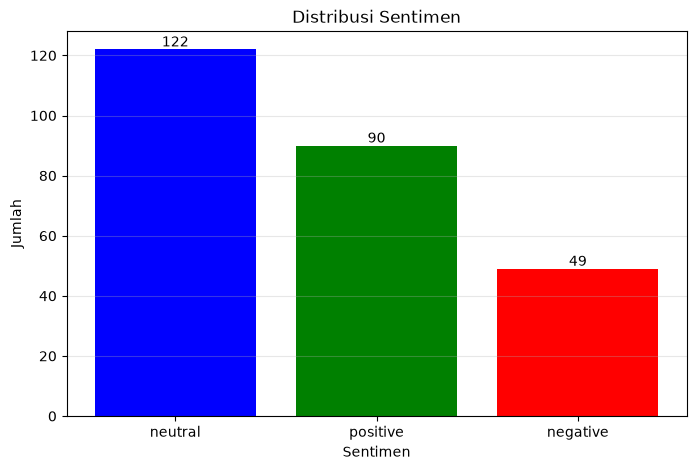

sentiment
neutral     122
positive     90
negative     49
Name: count, dtype: int64

sentiment
neutral     46.7 %
positive    34.5 %
negative    18.8 %
Name: count, dtype: str


In [6]:
import matplotlib.pyplot as plt

sentiment_counts = data['sentiment'].value_counts()
warna = {'positive': 'green', 'negative': 'red', 'neutral': 'blue'}

plt.figure(figsize=(8, 5))
bars = plt.bar(sentiment_counts.index, sentiment_counts.values,
               color=[warna[s] for s in sentiment_counts.index])
for bar, num in zip(bars, sentiment_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, num + 1, str(num), ha='center')
plt.title('Distribusi Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.grid(axis='y', alpha=.3)
plt.show()

print(sentiment_counts)
print()
print((sentiment_counts / len(data) * 100).round(1).astype(str) + " %")

## (Tambahan) Perbandingan Naive Bayes vs Neural Network
Seberapa sering kedua model memberi label yang sama? Ini bisa jadi bahan analisis tambahan di laporan.

In [7]:
X_feat = feature_bow.transform(data['full_text'])
data['sentiment_nn'] = model_nn.predict(X_feat)

setuju = (data['sentiment'] == data['sentiment_nn']).mean() * 100
print(f"Kedua model memberi label sama pada {setuju:.1f}% tweet\n")
print(pd.crosstab(data['sentiment'], data['sentiment_nn'],
                  rownames=['Naive Bayes'], colnames=['Neural Network']))

Kedua model memberi label sama pada 69.3% tweet

Neural Network  negative  neutral  positive
Naive Bayes                                
negative              38        6         5
neutral               21       90        11
positive              10       27        53


## Word Cloud dan kata yang sering muncul
Stopwords (yang, di, dan, ...) dan keyword dibuang dulu supaya kata yang tampil lebih bermakna. Di laprak contoh stopwords tidak dibuang, sehingga kata teratas didominasi "yg", "di", "yang".

In [8]:
from wordcloud import WordCloud
from collections import Counter
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords as sw

stopwords = set(sw.words('indonesian')) | set(sw.words('english')) | {
    'yg', 'ga', 'gak', 'nggak', 'ngga', 'aja', 'sih', 'nih', 'tuh', 'dong', 'deh', 'kok',
    'nya', 'udah', 'dah', 'gue', 'gw', 'lu', 'lo', 'kalo', 'jd', 'dgn', 'utk', 'tdk', 'amp', KEYWORD}

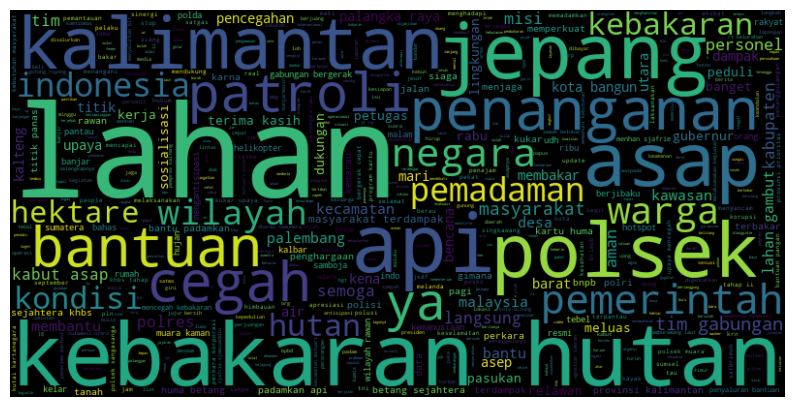

In [9]:
# 1. Word Cloud
data_text = ' '.join(data['full_text'].astype(str).tolist())

wc = WordCloud(stopwords=stopwords, background_color='black', max_words=500,
               width=800, height=400).generate(data_text)

plt.figure(figsize=(10, 10))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

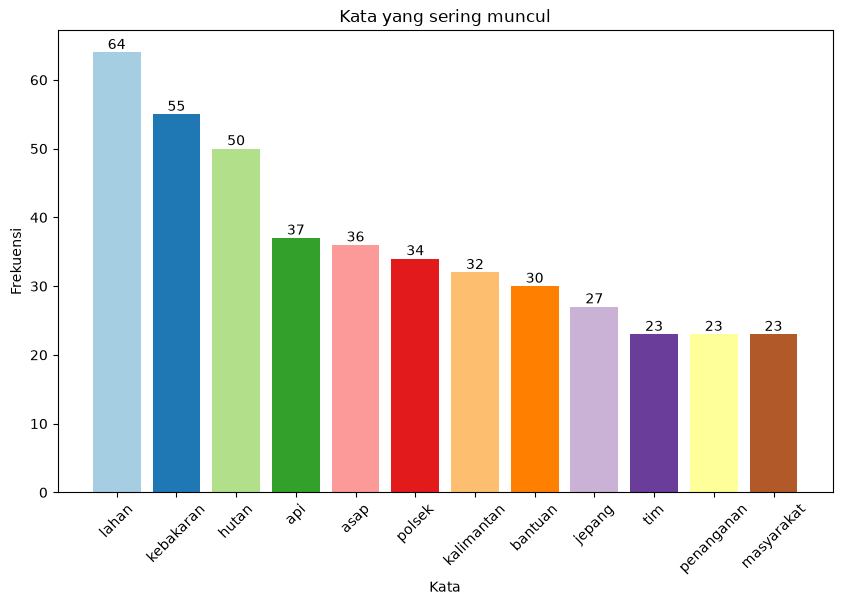

In [10]:
# 2. Bar chart kata yang paling sering muncul
words = [w for w in data_text.split() if w not in stopwords and len(w) > 2]
top_words = Counter(words).most_common(12)
kata, counts = zip(*top_words)

colors = plt.cm.Paired(range(len(kata)))
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(kata, counts, color=colors)
ax.set_xlabel('Kata')
ax.set_ylabel('Frekuensi')
ax.set_title('Kata yang sering muncul')
ax.set_xticks(range(len(kata)))
ax.set_xticklabels(kata, rotation=45)
for bar, num in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, num + 0.5, str(num), ha='center')
plt.show()

## (Tambahan) Contoh tweet per sentimen
Berguna untuk mengecek apakah label dari model masuk akal.

In [11]:
for s in ['positive', 'negative', 'neutral']:
    print(f"--- {s.upper()} ---")
    for t in data[data['sentiment'] == s]['full_text'].head(5):
        print("•", t[:130])
    print()

--- POSITIVE ---
• polsek menjalin edukasi warga cegah karhutla sejak dini
• btw daerah karhutla udah hujan belum yaa semoga aja udah ya allah
• terharu kementerian pertahanan jepang resmi mengakhiri operasi bantuan penanggulangan karhutla di k
• tidak mengenal lelah di tengah asap dan panasnya api langkah terus bergerak demi memadamkan karhutla tak peduli siang ataupun mala
• kemarau panjang tingkatkan kewaspadaan bhabinkamtibmas manggar aipda edy wahyudi mengajak warga bersama sama mencegah karhutla dan

--- NEGATIVE ---
• penegakan hukum karhutla memang bergerak tetapi pergerakannya belum sama antara pelaku perorangan dan korporasi yang perlu dilihat
• kejagung menerima spdp perkara pidana karhutla sepanjang januari september perkara perorangan dan perkara korporasi sebanyak perka
• cegah karhutla makin meluas polsek kota bangun ingatkan warga soal bahaya membakar lahan kukar upaya mencegah kebakaran hutan dan 
• jadi mulai sekarang kalo bisa kita bahas yg lebih urgensi aja ya misal